## Importing the necessary libraries

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import numpy as np


# Data preparation

## 1-Data Inspection

#### Load data

In [90]:
df_hit=pd.read_csv('homeintunisia_maison_vente.csv')

In [91]:
df_mub=pd.read_csv('mubawab_maison_vente.csv')

In [92]:
df_star=pd.read_csv('properstar_maison_acheter.csv')

In [93]:
df_remax=pd.read_csv('remax_maison_acheter.csv')

In [94]:
euro_to_dinar=3.38

#### Inspect data

In [95]:
df_hit.head(3)

,link,title,address,price,type,Référence,Pièces,Surface,Surface totale,Type de chauffage,...,Sous-sol 6 m²,Terrain 572 m²,Terrains 2032 m²,Terrains 1000 m²,Terrains 1291 m²,Terrains 1293 m²,Terrains 1667 m²,Terrains 8940 m²,Terrains 5160 m²,Appartement 109 m²
0,https://www.homeintunisia.com/fr/propri%C3%A9t...,À Vendre – Villa spacieuse à Khzema,Sousse Khezama,1 300 000 TND,Maison,85853297,6 pièces,350 m²,450 m²,"Radiateur, Climatisation",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.homeintunisia.com/fr/propri%C3%A9t...,Villa neuve à vendre Kantaoui côté mer,El Kantaoui,2 400 000 TND,Maison,85839722,12 pièces,494 m²,600 m²,Central,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.homeintunisia.com/fr/propri%C3%A9t...,🏰 VILLA COLONIALE PRESTIGE AVEC PISCINE – LA M...,La Marsa,1 730 400 TND,Maison,85836272,9 pièces,600 m²,600 m²,"Radiateur, Central",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
df_mub.head(3)

,link,title,address,price,m²,Chambres,Salles de bains,Type de bien,Standing,État,...,Réfrigérateur,Machine à laver,Orientation,Salle de bain,Vue sur mer,Meublé,Pièce,Chambre,Surface habitable,Surface extérieure
0,https://www.mubawab.tn/fr/pa/7940166/splendide...,Splendide villa à vendre à Gammarth. Superfici...,Gammarth à La Marsa,856 000 TND,405.0,4.0,5.0,Villa,Haut standing,En cours de construction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.mubawab.tn/fr/pa/7845699/duplex-de...,Duplex de luxe à vendre,Les Jardins de Carthage à Le Kram,Prix à consulter,265.0,3.0,3.0,Villa,Haut standing,En cours de construction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.mubawab.tn/fr/a/8022200/villa-seba...,Villa sebastian,Hammamet Sud à Hammamet,892 000 TND,485.0,4.0,4.0,Villa,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
df_star.head(3)

,link,class,title,description,address,price,latitude,longitude,Pièces,Etages,...,Ascenseur,Tennis,Centre de remise en forme,Salle à manger,Hammam,Cave à vin,Lave-vaisselle,Piscine extérieure,Studio de yoga,Suites d'hôtes
0,https://www.properstar.fr/annonce/103912219,maison,"Maison à vendre à Djerba Midoun, Tunisie",Villa • 7 pce(s) • 4 chambres • 3 sdb • 402 m²...,Djerba Midoun,117 049 €,33.775472,10.958095,7.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.properstar.fr/annonce/101542965,maison,"Maison à vendre à Hammamet, Tunisie",Maison • 5 pce(s) • 4 chambres • 3 sdb • 280 m...,Hammamet,324 994 €,36.407257,10.622471,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.properstar.fr/annonce/106123620,maison,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
df_remax.head(3)

,link,title,prix,payment_method,latitude,longitude,address,statut_marche,Nombre de pièces,Nombre de chambres,...,Équipements inclus,Partiellement meublé,Est,Montagnes,Vue sur montagne,Buanderie,Pieds dans l'eau,Wooden Window Frames,Baroque,Style colonial
0,https://www.remax.com.tn/fr-tn/biens/villa/ven...,Villa - Vente - Ben Arous Ben Arous Tunisie,"680,000 TND",NaN,36.743500,10.231976,Ben Arous - Ben Arous - Tunisie,Nouveau sur le marché,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.remax.com.tn/fr-tn/biens/villa/ven...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.remax.com.tn/fr-tn/biens/villa/ven...,Villa - Vente - Sidi El Béchir Tunis Tunisie,Nous consulter,NaN,36.792686,10.179430,Sidi El Béchir - Tunis - Tunisie,A renover,15.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### shape of the data (number of rows, number of columns)

In [99]:
df_hit.shape

(165, 408)

In [100]:
df_mub.shape

(4118, 49)

In [101]:
df_star.shape

(526, 57)

In [102]:
df_remax.shape

(129, 119)

##### column names

In [103]:
df_hit.columns

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       ...
       'Sous-sol 6 m²', 'Terrain 572 m²', 'Terrains 2032 m²',
       'Terrains 1000 m²', 'Terrains 1291 m²', 'Terrains 1293 m²',
       'Terrains 1667 m²', 'Terrains 8940 m²', 'Terrains 5160 m²',
       'Appartement 109 m²'],
      dtype='object', length=408)

In [104]:
df_mub.columns

Index(['link', 'title', 'address', 'price', 'm²', 'Chambres',
       'Salles de bains', 'Type de bien', 'Standing', 'État', 'latitude',
       'longitude', 'Pièces', 'Jardin', 'Terrasse', 'Piscine',
       'Antenne parabolique', 'Climatisation', 'Chauffage central', 'Sécurité',
       'Double vitrage', 'Porte blindée', 'Cuisine équipée', 'Four', 'Etat',
       'Etat du bien', 'Type du sol', 'Livraison:', 'Garage', 'Entre-seul',
       'Salon européen', 'Nombre d'étages', 'Surface de la parcelle',
       'Vue sur les montagnes', 'Micro-ondes', 'Cheminée', 'Ascenseur',
       'Concierge', 'Chambre rangement', 'Réfrigérateur', 'Machine à laver',
       'Orientation', 'Salle de bain', 'Vue sur mer', 'Meublé', 'Pièce',
       'Chambre', 'Surface habitable', 'Surface extérieure'],
      dtype='object')

In [105]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Habitable',
       'Terrain', 'Total', 'Piscine', 'Terrasse', 'Type',
       'Année de construction', 'Places de parc intérieures', 'Jardin',
       'Balcon', 'Condition', 'Chauffage', 'Climatisation', 'Meublé',
       'Parking', 'Standing', 'Eau chaude', 'Déchets des eaux usées', 'Alarme',
       'Année de rénovation', 'Interphone', 'Jacuzzi',
       'Recharge de véhicules électriques', 'Télévision par satellite',
       'Internet', 'Machine à laver', 'Sauna', 'Barbecue', 'Concierge 24/7',
       'Sécurité', 'Garage', 'Piscine intérieure', 'Ascenseur', 'Tennis',
       'Centre de remise en forme', 'Salle à manger', 'Hammam', 'Cave à vin',
       'Lave-vaisselle', 'Piscine extérieure', 'Studio de yoga',
       'Suites d'hôtes'],
      dtype='object')

#### matching columns

In [106]:
cols_mub=['price','address', 'm²', 'Pièces','Salles de bains','Salle de bain', 'Terrasse',
          'Meublé','Climatisation','Chauffage central', 'Sécurité',"Nombre d'étages",
          'latitude', 'longitude', 'Chambres', 'Garage', 'Jardin', 'Piscine']
cols_renamed = {
    'm²': 'total_area',
    'Pièces': 'rooms',
    'Chambres': 'bedrooms',
    'Salles de bains': 'bathrooms',
    'Salle de bain': 'bathroom',
    'Jardin': 'garden',
    'Garage': 'garage',
    'Piscine': 'pool',
    'Chauffage central': 'heating',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'Terrasse': 'terrace',
    'Climatisation': 'air_conditioning',
    'Surface de la parcelle': 'total_area',  #
    'Meublé': 'furnished',
    "Sécurité":"security",
    "Nombre d'étages":"floor"
}
# Assuming df is your DataFrame
df_mub = df_mub[cols_mub].rename(columns=cols_renamed)
df_mub.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'bathroom',
       'terrace', 'furnished', 'air_conditioning', 'heating', 'security',
       'floor', 'latitude', 'longitude', 'bedrooms', 'garage', 'garden',
       'pool'],
      dtype='object')

In [107]:
hit_cols=df_hit.columns
hit_cols[0:20]

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       'Énergie de chauffage', 'Moyen de chauffage', 'Type d'eau chaude',
       'Moyen d'eau chaude', 'Eaux usées', 'État', 'Étage', 'Exposition',
       'Vue', 'Salon'],
      dtype='object')

In [108]:
cols_hit=['price','Pièces','address','Surface totale','Salles de bains','Salle de bains','Étage',
    'Type de chauffage','Piscine','latitude','longitude','Air conditionné','Meublé',
    'Piscine en copropriété','Terrasse','Alarme','Vidéo surveillance','Garage','Jardin',
    'Chambres']
df_hit=df_hit[cols_hit]
# Using pandas rename method directly
df_hit = df_hit.rename(columns={
    'Pièces': 'rooms',
    'Surface totale': 'total_area',
    'Étage': 'floor_number',
    'Salon': 'living_room',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Piscine en copropriété': 'shared_pool',
    'Salles de bains':'bathrooms',
    'Salle de bains':'bathroom',
    'Type de chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'alarm',
    'Vidéo surveillance':'video_surveillance',
    'Garage':'garage',
    'Jardin':'garden'
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'bathrooms', 'bathroom',
       'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms'],
      dtype='object')

In [109]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Habitable',
       'Terrain', 'Total', 'Piscine', 'Terrasse', 'Type',
       'Année de construction', 'Places de parc intérieures', 'Jardin',
       'Balcon', 'Condition', 'Chauffage', 'Climatisation', 'Meublé',
       'Parking', 'Standing', 'Eau chaude', 'Déchets des eaux usées', 'Alarme',
       'Année de rénovation', 'Interphone', 'Jacuzzi',
       'Recharge de véhicules électriques', 'Télévision par satellite',
       'Internet', 'Machine à laver', 'Sauna', 'Barbecue', 'Concierge 24/7',
       'Sécurité', 'Garage', 'Piscine intérieure', 'Ascenseur', 'Tennis',
       'Centre de remise en forme', 'Salle à manger', 'Hammam', 'Cave à vin',
       'Lave-vaisselle', 'Piscine extérieure', 'Studio de yoga',
       'Suites d'hôtes'],
      dtype='object')

In [110]:
cols_star=['price','address','latitude','longitude','Pièces','Etages','Chambres','Salles de bains',
        'Total','Piscine', 'Terrasse','Jardin','Chauffage', 'Climatisation','Meublé',
        'Alarme','Garage','Piscine intérieure']
df_star=df_star[cols_star]
# Using pandas rename method directly
df_star = df_star.rename(columns={
    'Pièces': 'rooms',
    'Total': 'total_area',
    'Étage': 'floor_number',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Climatisation': 'air_conditioning',
    'Meublé': 'furnished',
    'Piscine intérieure': 'indoor_pool',
    'Salles de bains':'bathrooms',
    'Chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    'Etages':'floor'
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'bathrooms', 'bathroom',
       'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms'],
      dtype='object')

In [111]:
remax_cols=df_remax.columns
remax_cols[0:30]

Index(['link', 'title', 'prix', 'payment_method', 'latitude', 'longitude',
       'address', 'statut_marche', 'Nombre de pièces', 'Nombre de chambres',
       'Nombre salles de bain', 'm²', 'Surface Terrain (m²)',
       'Surface constructible (m²)', 'Places de parking', 'Nombre d'étages',
       'Etage', 'Nombre de WC', 'Balcon', 'Garage', 'Jardin', 'Terrasse',
       'Terrasse sur le toit', 'Travaux à prévoir', 'Cuisine',
       'Cuisine/Salle à manger', 'Hall d'entrée', 'Rénovation à prévoir',
       'Habitation', 'Vue dégagée'],
      dtype='object')

In [112]:
cols_remax=['prix','latitude','longitude','Nombre de pièces','Nombre de chambres','Nombre salles de bain',
            'm²',"Nombre d'étages", 'Garage', 'Jardin', 'Terrasse','Air Conditionné',
            'Piscine','Meublé','Système de sécurité', 'Système de surveillance','Camera de sécurité',
            'Chauffage Central','Chauffage au sol']
df_remax=df_remax[cols_remax]
# Using pandas rename method directly
df_remax = df_remax.rename(columns={
    'prix':'price',
    'Nombre de pièces': 'rooms',
    'm²': 'total_area',
    "Nombre d'étages": 'floor',
    'Nombre de chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air Conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Nombre salles de bain':'bathrooms',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    'Etages':'floor'
})
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'Chauffage Central',
       'Chauffage au sol'],
      dtype='object')

## 2- Data Cleaning

### a-standardizing Formats

#### -df_hit

In [113]:
df_hit["price"].sample(5)

71     2 060 000 TND
74     3 182 700 TND
128    2 060 000 TND
28       950 000 TND
43       300 000 TND
Name: price, dtype: object

In [114]:
print(df_hit.shape)
df_hit=df_hit[df_hit['price']!="Prix sur demande"]
print(df_hit.shape)

(165, 20)
(156, 20)


In [115]:
# Filter rows where the price column contains the word "Moin"
mois_df = df_hit[df_hit['price'].astype(str).str.contains('Mois', case=False)]
jour_df=df_hit[df_hit['price'].astype(str).str.contains('Jour', case=False)]
semaine_df=df_hit[df_hit['price'].astype(str).str.contains('Semaine', case=False)]
year_df=df_hit[df_hit['price'].astype(str).str.contains('An', case=False)]
print(mois_df.shape)
print(jour_df.shape)
print(semaine_df.shape)

(0, 20)
(0, 20)
(0, 20)


In [116]:
print(df_hit.shape)
df_hit = df_hit[~df_hit['price'].astype(str).str.contains('Mois|Jour|Semaine|An', case=False)]
print(df_hit.shape)

(156, 20)
(156, 20)


In [117]:
# First, remove 'TND' from the price column
df_hit['price'] = df_hit['price'].str.replace('TND', '')
# Remove all types of spaces (including non-breaking spaces and other whitespace)
df_hit['price'] = df_hit['price'].str.replace(r'\s+', '', regex=True)
# Now convert to float
df_hit['price'] = df_hit['price'].astype(float)

In [118]:
df_hit['rooms'].value_counts()

rooms
5 pièces     23
4 pièces     21
6 pièces     20
10 pièces    14
3 pièces     13
7 pièces     12
8 pièces     12
9 pièces      6
11 pièces     2
13 pièces     2
15 pièces     2
1 pièce       1
12 pièces     1
14 pièces     1
19 pièces     1
2 pièces      1
20 pièces     1
16 pièces     1
Name: count, dtype: int64

In [119]:
df_hit['rooms']=df_hit['rooms'].str.replace(' pièces','')
df_hit['rooms']=df_hit['rooms'].str.replace(' pièce','')
df_hit['rooms']=df_hit['rooms'].astype(float)
df_hit['rooms'].value_counts()

rooms
5.0     23
4.0     21
6.0     20
10.0    14
3.0     13
7.0     12
8.0     12
9.0      6
11.0     2
13.0     2
15.0     2
1.0      1
12.0     1
14.0     1
19.0     1
2.0      1
20.0     1
16.0     1
Name: count, dtype: int64

In [120]:
df_hit['total_area'].value_counts().head(3)

total_area
450 m²    6
600 m²    6
300 m²    5
Name: count, dtype: int64

In [121]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['total_area']  # List of size-related columns
for col in columns_to_transform:
    df_hit = clean_size_column(df_hit, col)
# Check the cleaned columns
df_hit[columns_to_transform].sample(5)


,total_area
130,1200.0
69,403.0
110,515.0
93,450.0
124,200.0


In [122]:
df_hit['pool'] = df_hit[['pool', 'shared_pool']].max(axis=1)
df_hit.drop(columns=['shared_pool'],inplace=True)

In [123]:
df_hit['bathrooms'] = df_hit[['bathroom', 'bathrooms']].max(axis=1)
df_hit.drop(columns=['bathroom'],inplace=True)

In [124]:
df_hit['security']=0
df_hit['security']=df_hit[['video_surveillance', 'alarm']].max(axis=1)
df_hit=df_hit.drop(columns=['video_surveillance', 'alarm'],axis=1)
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'bathrooms', 'floor_number',
       'heating', 'pool', 'latitude', 'longitude', 'air_conditioning',
       'furnished', 'terrace', 'garage', 'garden', 'bedrooms', 'security'],
      dtype='object')

In [125]:
# Set to 1 for properties with any type of heating
df_hit["heating"]=df_hit["heating"].fillna(0)
df_hit["heating"]=df_hit["heating"].apply(lambda x: 0 if x=="Sans chauffage" else 1)
print(df_hit['heating'].value_counts())

heating
1    154
0      2
Name: count, dtype: int64


In [126]:
df_hit['floor_number'].value_counts()

floor_number
Rez-de-chaussée               45
Plain-pied                    14
Rez-de-chaussée / 2 étages    12
Rez-de-chaussée / 1 étage     11
1er                            4
Plain-pied / 1 étage           3
Rez-de-jardin / 2 étages       2
Plain-pied / 3 étages          2
Rez-de-chaussée / 3 étages     2
1er étage / 1                  1
Plain-pied / 2 étages          1
Surélevé                       1
Rez-de-jardin                  1
2ème                           1
6ème                           1
2ème étage / 2                 1
Name: count, dtype: int64

In [127]:
import re

# Create a new column for the extracted floor number
df_hit['floor_numeric'] = None

# Function to extract floor number
def extract_floor_number(floor_str):
    if not isinstance(floor_str, str):
        return None
        
    # Handle special cases
    if 'Rez-de-chaussée' in floor_str or 'Rez-de-jardin' in floor_str:
        return 0
    if 'Plain-pied' in floor_str:
        return 0
    if 'Surélevé' in floor_str:
        return 0.5
        
    # Extract floor number from strings like "1er", "2ème", etc.
    match = re.search(r'^(\d+)', floor_str)
    if match:
        return int(match.group(1))
        
    # Extract from patterns like "2ème étage / 4"
    match = re.search(r'^(\d+)[^\d]+', floor_str)
    if match:
        return int(match.group(1))
        
    return None

# Apply the function to the floor_number column
df_hit['floor_numeric'] = df_hit['floor_number'].apply(extract_floor_number)

# Convert to float
df_hit['floor_numeric'] = df_hit['floor_numeric'].astype(float)

# Check the results
print(df_hit['floor_numeric'].value_counts())

floor_numeric
0.0    93
1.0     5
2.0     2
0.5     1
6.0     1
Name: count, dtype: int64


In [128]:
df_hit=df_hit.drop(columns=['floor_number'],axis=1)
df_hit=df_hit.rename(columns={'floor_numeric':'floor'})

In [129]:
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'bathrooms', 'heating',
       'pool', 'latitude', 'longitude', 'air_conditioning', 'furnished',
       'terrace', 'garage', 'garden', 'bedrooms', 'security', 'floor'],
      dtype='object')

#### df_mub

In [130]:
print(df_mub.shape)
df_mub=df_mub[df_mub['price']!="Prix à consulter"]
print(df_mub.shape)

(4118, 18)
(3290, 18)


In [131]:
df_mub['price'].head(10)

0       856 000 TND
2       892 000 TND
4     1 250 000 TND
5     1 150 000 TND
7     2 200 000 TND
8       190 000 TND
9       980 000 TND
10      200 000 TND
12      945 000 TND
13    3 000 000 TND
Name: price, dtype: object

In [132]:
# Now you can use this in your code

for idx, row in df_mub.iterrows():
    price_ch = df_mub.loc[idx, 'price']
    position_tnd = price_ch.find('TND')
    position_eur=price_ch.find('EUR')
    if position_tnd !=-1:
        price = price_ch.replace('TND','') # remove the currency symbo
        price=price.replace(' ','')
        price=float(price)
    elif position_eur!=-1:
        price = price_ch.replace('EUR','')
        price=price.replace(' ','')
        price=float(price) * euro_to_dinar
    df_mub.loc[idx, "price"] = price
df_mub['price']=df_mub['price'].astype(float)

In [133]:
"""
df_mub_location=df_mub_location[df_mub_location['price']!="Prix à consulter"]
df_mub_location['price']=df_mub_location['price'].str.replace('TND','')
df_mub_location['price']=df_mub_location['price'].str.replace(' ','')
# Function to extract the first price value
def extract_first_price(price_str):
    # Pattern to match the first number followed by TND
    idx=price_str.find("B")
    if idx!=-1:
        price_str=price_str[:idx]
    return price_str
# To apply to the entire price column:
df_mub_location["price"] = df_mub_location["price"].apply(extract_first_price)
"""

'\ndf_mub_location=df_mub_location[df_mub_location[\'price\']!="Prix à consulter"]\ndf_mub_location[\'price\']=df_mub_location[\'price\'].str.replace(\'TND\',\'\')\ndf_mub_location[\'price\']=df_mub_location[\'price\'].str.replace(\' \',\'\')\n# Function to extract the first price value\ndef extract_first_price(price_str):\n    # Pattern to match the first number followed by TND\n    idx=price_str.find("B")\n    if idx!=-1:\n        price_str=price_str[:idx]\n    return price_str\n# To apply to the entire price column:\ndf_mub_location["price"] = df_mub_location["price"].apply(extract_first_price)\n'

In [134]:
df_mub['total_area'].sample(3)

512     600.0
201     305.0
1171     80.0
Name: total_area, dtype: float64

In [135]:
df_mub['bathrooms'] = df_mub[['bathroom', 'bathrooms']].max(axis=1)
df_mub.drop(columns=['bathroom'],inplace=True)

In [136]:
df_mub['floor'].value_counts()

floor
2.0    264
1.0    206
3.0     72
4.0      9
Name: count, dtype: int64

#### Df star

In [137]:
df_star["total_area"].sample(2)

446    334 m²
121    925 m²
Name: total_area, dtype: object

In [138]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['total_area']  # List of size-related columns
for col in columns_to_transform:
    df_star = clean_size_column(df_star, col)
# Check the cleaned columns
df_star[columns_to_transform].sample(5)


,total_area
17,330.0
178,NaN
194,790.0
302,344.0
15,260.0


In [139]:
df_star['price'].head(10)

0    117 049 €
1    324 994 €
2          NaN
3          NaN
4          NaN
5          NaN
6    331 542 €
7    453 566 €
8    702 296 €
9    248 730 €
Name: price, dtype: object

In [140]:
#update the price column
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace('€','') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace('\u202f', '') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace(' ','') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: x.strip() if isinstance(x, str) else x)
df_star['price'] = pd.to_numeric(df_star['price'], errors='coerce')
df_star['price']=df_star['price'].apply(lambda x : x* euro_to_dinar)
df_star['price'].head(10)


0     395625.62
1    1098479.72
2           NaN
3           NaN
4           NaN
5           NaN
6    1120611.96
7    1533053.08
8    2373760.48
9     840707.40
Name: price, dtype: float64

In [141]:
df_star["garden"].value_counts().head(5)

garden
1         11
400 m²     1
216 m²     1
270 m²     1
612 m²     1
Name: count, dtype: int64

In [142]:
df_star["heating"].value_counts().head(5)


heating
Chauffage central, Individuel, Gaz           83
Radiateur, Individuel, Gaz                   19
Gaz                                          18
Radiateur, Individuel, Electrique            14
Chauffage central, Individuel, Electrique     9
Name: count, dtype: int64

In [143]:
def handle_data(df_func,col):
    """
    This function is used to transform the data to binary:
    1. If the value is not 0, then the value is 1.
    2. If the value is 0 or NaN, then the value is 0.
    """
    df_func[col].fillna(0,inplace=True)
    df_func[col] = df_func[col].apply(lambda x: 1 if x != 0.0 else 0)
    return df_func
cols_transform_one=['heating','garden']
for col in cols_transform_one:
    df_star=handle_data(df_star,col)

C:\Users\MSI\AppData\Local\Temp\ipykernel_4424\3694022162.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_func[col].fillna(0,inplace=True)


In [144]:
df_star['pool'] = df_star[['pool', 'indoor_pool']].max(axis=1)
df_star.drop(columns=['indoor_pool'],inplace=True)

#### Df remax

In [145]:
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'Chauffage Central',
       'Chauffage au sol'],
      dtype='object')

In [146]:
df_remax['heating']=0
df_remax['heating'] = df_remax[['Chauffage au sol','Chauffage Central']].max(axis=1)
df_remax.drop(columns=['Chauffage au sol','Chauffage Central'],inplace=True)
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'heating'],
      dtype='object')

In [147]:
df_remax['security']=0
df_remax['security'] = df_remax[['Système de sécurité','Système de surveillance', 'Camera de sécurité']].max(axis=1)
df_remax.drop(columns=['Système de sécurité','Système de surveillance', 'Camera de sécurité'],inplace=True)
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'heating', 'security'],
      dtype='object')

In [148]:
df_remax=df_remax[df_remax['price']!='Nous consulter']
df_remax['price']=df_remax['price'].str.replace(' TND','')
df_remax['price']=df_remax['price'].str.replace(',','')
df_remax['price']=df_remax['price'].astype(float)

In [149]:
df_remax['total_area'].value_counts().head(5)

total_area
568      5
1,651    5
700      5
625      5
412      5
Name: count, dtype: int64

In [150]:
df_remax['total_area']=df_remax['total_area'].str.replace(',','')
df_remax['total_area']=df_remax['total_area'].astype(float)

In [151]:
df_remax['floor'].value_counts()

floor
1.0    22
2.0    13
3.0     5
Name: count, dtype: int64

In [152]:
df_remax['floor'].value_counts()

floor
1.0    22
2.0    13
3.0     5
Name: count, dtype: int64

In [153]:
df_remax['terrace'].value_counts()

terrace
1.0    60
Name: count, dtype: int64

#### Combine dataframes

In [154]:
df=pd.concat([df_mub,df_hit,df_star,df_remax])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4081 entries, 0 to 128
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             4016 non-null   float64
 1   address           3936 non-null   object 
 2   total_area        3812 non-null   float64
 3   rooms             3345 non-null   float64
 4   bathrooms         3249 non-null   float64
 5   terrace           2612 non-null   float64
 6   furnished         531 non-null    float64
 7   air_conditioning  2005 non-null   float64
 8   heating           2200 non-null   float64
 9   security          1118 non-null   float64
 10  floor             891 non-null    float64
 11  latitude          3990 non-null   float64
 12  longitude         3990 non-null   float64
 13  bedrooms          3294 non-null   float64
 14  garage            1964 non-null   float64
 15  garden            2914 non-null   float64
 16  pool              1571 non-null   float64
dtypes

In [155]:
df.shape

(4081, 17)

### b-handle missing values

#### Droping columns with high missing values 

In [156]:
df.isna().sum().sort_values(ascending=False)

furnished           3550
floor               3190
security            2963
pool                2510
garage              2117
air_conditioning    2076
heating             1881
terrace             1469
garden              1167
bathrooms            832
bedrooms             787
rooms                736
total_area           269
address              145
latitude              91
longitude             91
price                 65
dtype: int64

pool/elevator/air_conditioning/furnished/heating NaN values means 0

In [157]:
percentage_missing=df.isnull().sum()*100/len(df)
percentage_missing.sort_values(ascending=False)

furnished           86.988483
floor               78.167116
security            72.604754
pool                61.504533
garage              51.874541
air_conditioning    50.869885
heating             46.091644
terrace             35.996079
garden              28.595932
bathrooms           20.387160
bedrooms            19.284489
rooms               18.034795
total_area           6.591522
address              3.553051
latitude             2.229846
longitude            2.229846
price                1.592747
dtype: float64

In [322]:
df_clean=df.drop(columns=['floor'],axis=1)
df_clean=df_clean.dropna(subset=['price','latitude','longitude'])

#### Replace missing values with mean,mode,median,0 or 1
mode => categorical distribution

median => skewed distribution

mean => normal distribution

0/1 => when we know that the value is normally 1 or 0

In [69]:
df_clean.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool'],
      dtype='object')

In [70]:
columns_with_zeros=['pool','garden','garage','security','heating','terrace',
                    'air_conditioning','furnished']
for col in columns_with_zeros:
    df_clean[col]=df_clean[col].fillna(0)
columns_with_one=['bathrooms']
for col in columns_with_one:
    df_clean[col]=df_clean[col].fillna(1)

In [71]:
percentage_missing=df_clean.isnull().sum()*100/len(df_clean)
percentage_missing.sort_values(ascending=False)

bedrooms            17.819549
rooms               16.491228
total_area           4.962406
address              1.503759
price                0.000000
bathrooms            0.000000
terrace              0.000000
furnished            0.000000
air_conditioning     0.000000
heating              0.000000
security             0.000000
latitude             0.000000
longitude            0.000000
garage               0.000000
garden               0.000000
pool                 0.000000
dtype: float64

In [72]:
mode_columns=["rooms","bedrooms"]
for col in mode_columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


C:\Users\MSI\AppData\Local\Temp\ipykernel_15968\2566872868.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


In [73]:
def plot_distribution(data,title,xlabel):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True)  # kde=True will add a kernel density estimate curve to visualize distribution smoothly
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.show()

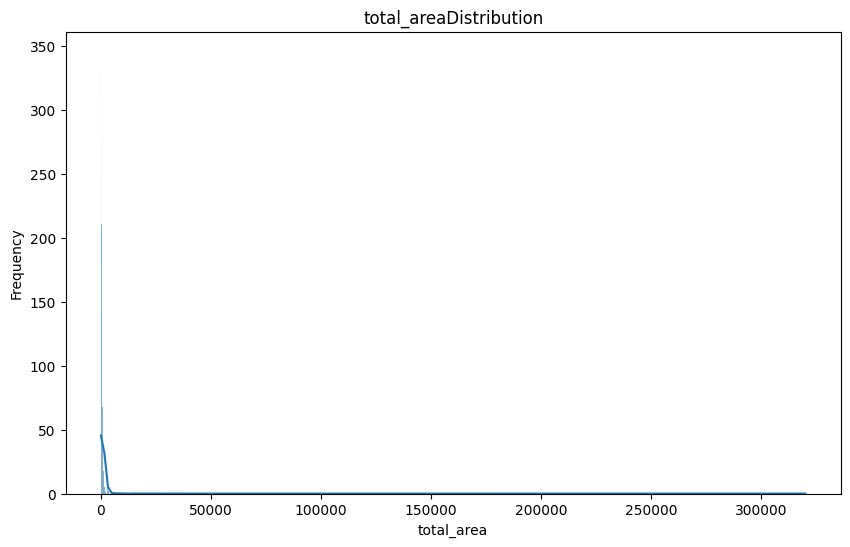

In [74]:
for col in ['total_area']:
    plot_distribution(df_clean[col],col + 'Distribution',col)

In [75]:
df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)

C:\Users\MSI\AppData\Local\Temp\ipykernel_15968\2492172101.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)


#### address column

In [76]:
df_missing=df_clean[df_clean['address'].isnull()]
df_full=df_clean[df_clean['address'].notna()]
print(len(df_missing))

60


In [77]:
# Use Nominatim API to fill in missing addresses
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
# Initialize the geocoder with rate limiting
geolocator = Nominatim(user_agent="tunisia_property_analysis")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)
# Function to extract location info from coordinates
def get_location_info(lat, lon):
    try:
        location = geocode((lat, lon), language='fr')
        if location and location.raw.get('address'):
            address = location.raw['address']
            municipality = address.get('city') or address.get('town') or address.get('village') or address.get('suburb')
            return municipality
        return None
    except Exception as e:
        time.sleep(2)
        return None
# Create a copy of df_missing
df_filled = df_missing.copy()
# Process in batches
batch_size = 10
total = len(df_missing)
municipalities = []

for i in range(0, total, batch_size):
    batch = df_missing.iloc[i:min(i + batch_size, total)]
    for _, row in batch.iterrows():
        municipality= get_location_info(row['latitude'], row['longitude'])
        municipalities.append(municipality)
    time.sleep(1)
# Add results to df_filled
df_filled['address'] = municipalities
# Combine with df_full

In [78]:
df_clean = pd.concat([df_full, df_filled])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3990 entries, 0 to 97
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             3990 non-null   float64
 1   address           3977 non-null   object 
 2   total_area        3990 non-null   float64
 3   rooms             3990 non-null   float64
 4   bathrooms         3990 non-null   float64
 5   terrace           3990 non-null   float64
 6   furnished         3990 non-null   float64
 7   air_conditioning  3990 non-null   float64
 8   heating           3990 non-null   float64
 9   security          3990 non-null   float64
 10  latitude          3990 non-null   float64
 11  longitude         3990 non-null   float64
 12  bedrooms          3990 non-null   float64
 13  garage            3990 non-null   float64
 14  garden            3990 non-null   float64
 15  pool              3990 non-null   float64
dtypes: float64(15), object(1)
memory usage: 529.9+ KB

In [79]:
print(df_clean.shape)
df_clean=df_clean.dropna(subset=['address'])
print(df_clean.shape)

(3990, 16)
(3977, 16)


### c- Handling outliers

#### Price column

we can't jsut remove outliers the normal way because some plecas have high price values like Marsa ,gammarth and some places have low prices so it is not logic to drop outliers without introducing some categorical place difference

In [80]:
print(df_clean['price'].min())
print(df_clean['price'].max())

0.0
900000000.0


In [81]:
print(df_clean.shape)
df_clean=df_clean[ (df_clean['price']>50000) & (df_clean['price']<9999999) ]
print(df_clean.shape)
print(df_clean['price'].min())
print(df_clean['price'].max())

(3977, 16)
(3895, 16)
55000.0
9168655.6


In [82]:
municipality_df=pd.read_csv('municipalities.csv')
municipality_df.head()

,governorate,municipality
0,Tunis,Tunis
1,Tunis,Le Bardo
2,Tunis,Le Kram
3,Tunis,La Goulette
4,Tunis,Carthage


In [83]:
print(municipality_df['governorate'].nunique())
print(municipality_df['governorate'].unique())


24
['Tunis' 'Ariana' 'Ben Arous' 'Manouba' 'Nabeul' 'Zaghouan' 'Bizerte'
 'Béja' 'Jendouba' 'Kef' 'Siliana' 'Sousse' 'Monastir' 'Mahdia' 'Sfax'
 'Kairouan' 'Kasserine' 'Sidi Bouzid' 'Gabès' 'Mednine' 'Tataouine'
 'Gafsa' 'Tozeur' 'Kebili']


In [84]:
print(municipality_df['municipality'].nunique())
print(municipality_df['municipality'].unique())


270
['Tunis' 'Le Bardo' 'Le Kram' 'La Goulette' 'Carthage' 'Sidi Bou Said'
 'La Marsa' 'Sidi Hassine' 'Ariana' 'La Soukra' 'Raoued'
 'Kalâat el-Andalous' 'Sidi Thabet' 'Ettadhamen-Mnihla' 'Ben Arous'
 'El Mourouj' 'Hammam Lif' 'Hammam Chott' 'Bou Mhel el-Bassatine'
 'Ezzahra' 'Radès' 'Mégrine' 'Mohamedia-Fouchana' 'Mornag' 'Khalidia'
 'Manouba' 'Den Den' 'Douar Hicher' 'Oued Ellil' 'Mornaguia'
 'Borj El Amri' 'Djedeida' 'Tebourba' 'El Battan' 'Nabeul' 'Dar Chaabane'
 'Béni Khiar' 'El Maâmoura' 'Somâa' 'Korba' 'Tazerka' 'Menzel Temime'
 'Menzel Horr' 'El Mida' 'Kelibia' 'Azmour' 'Hammam Ghezèze' 'Dar Allouch'
 'El Haouaria' 'Takelsa' 'Soliman' 'Korbous' 'Menzel Bouzelfa'
 'Béni Khalled' 'Zaouiet Djedidi' 'Grombalia' 'Bou Argoub' 'Hammamet'
 'Zaghouan' 'Zriba' 'Bir Mcherga' 'Djebel Oust' 'El Fahs' 'Nadhour'
 'Bizerte' 'Sejnane' 'Mateur' 'Menzel Bourguiba' 'Tinja' 'Ghar al Milh'
 'Aousja' 'Menzel Jemil' 'Menzel Abderrahmane' 'El Alia' 'Ras Jebel'
 'Metline' 'Raf Raf' 'Béja' 'El Maâgoula' 

In [85]:
df_clean["municipality"]=None
df_clean["governorate"]=None

In [86]:
from thefuzz import process, fuzz
# Rename the misspelled columns
df_clean["municipality"] = df_clean["address"].apply(
  lambda x: process.extractOne(x, municipality_df["municipality"], scorer=fuzz.partial_ratio)[0]
)

In [87]:
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,bedrooms,garage,garden,pool,municipality,governorate
0,856000.0,Gammarth à La Marsa,405.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,36.876389,10.325278,4.0,0.0,0.0,0.0,La Marsa,None
2,892000.0,Hammamet Sud à Hammamet,485.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,36.388385,10.551504,4.0,1.0,1.0,1.0,Hammamet,None
4,1250000.0,Hammamet Nord à Hammamet,370.0,5.0,3.0,1.0,0.0,1.0,1.0,0.0,36.401080,10.614570,4.0,1.0,1.0,1.0,Hammamet,None
5,1150000.0,Hammamet Sud à Hammamet,550.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,36.401080,10.614570,4.0,1.0,1.0,1.0,Hammamet,None
7,2200000.0,Les Berges Du Lac 1 à La Marsa,438.0,8.0,4.0,1.0,0.0,1.0,1.0,1.0,36.835515,10.224176,6.0,1.0,1.0,1.0,La Marsa,None


In [88]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3895 entries, 0 to 97
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             3895 non-null   float64
 1   address           3895 non-null   object 
 2   total_area        3895 non-null   float64
 3   rooms             3895 non-null   float64
 4   bathrooms         3895 non-null   float64
 5   terrace           3895 non-null   float64
 6   furnished         3895 non-null   float64
 7   air_conditioning  3895 non-null   float64
 8   heating           3895 non-null   float64
 9   security          3895 non-null   float64
 10  latitude          3895 non-null   float64
 11  longitude         3895 non-null   float64
 12  bedrooms          3895 non-null   float64
 13  garage            3895 non-null   float64
 14  garden            3895 non-null   float64
 15  pool              3895 non-null   float64
 16  municipality      3895 non-null   object 
 17  go

In [89]:
municipality_lst=list(municipality_df['municipality'])
governorate_lst=list(municipality_df['governorate'])
print(len(municipality_lst))
print(len(governorate_lst))

270
270


we fill governorate based on the municipality , exemple : Manar => Ariana

In [90]:
# Create a dictionary mapping municipalities to governorates
municipality_to_governorate = dict(zip(municipality_lst, governorate_lst))
print(municipality_to_governorate)
# Create or update the governorate column using the mapping
df_clean['governorate'] = df_clean['municipality'].map(municipality_to_governorate)

{'Tunis': 'Tunis', 'Le Bardo': 'Tunis', 'Le Kram': 'Tunis', 'La Goulette': 'Tunis', 'Carthage': 'Tunis', 'Sidi Bou Said': 'Tunis', 'La Marsa': 'Tunis', 'Sidi Hassine': 'Tunis', 'Ariana': 'Ariana', 'La Soukra': 'Ariana', 'Raoued': 'Ariana', 'Kalâat el-Andalous': 'Ariana', 'Sidi Thabet': 'Ariana', 'Ettadhamen-Mnihla': 'Ariana', 'Ben Arous': 'Ben Arous', 'El Mourouj': 'Ben Arous', 'Hammam Lif': 'Ben Arous', 'Hammam Chott': 'Ben Arous', 'Bou Mhel el-Bassatine': 'Ben Arous', 'Ezzahra': 'Ben Arous', 'Radès': 'Ben Arous', 'Mégrine': 'Ben Arous', 'Mohamedia-Fouchana': 'Ben Arous', 'Mornag': 'Ben Arous', 'Khalidia': 'Ben Arous', 'Manouba': 'Manouba', 'Den Den': 'Manouba', 'Douar Hicher': 'Manouba', 'Oued Ellil': 'Manouba', 'Mornaguia': 'Manouba', 'Borj El Amri': 'Manouba', 'Djedeida': 'Manouba', 'Tebourba': 'Manouba', 'El Battan': 'Manouba', 'Nabeul': 'Nabeul', 'Dar Chaabane': 'Nabeul', 'Béni Khiar': 'Nabeul', 'El Maâmoura': 'Nabeul', 'Somâa': 'Nabeul', 'Korba': 'Nabeul', 'Tazerka': 'Nabeul', '

In [91]:
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,bedrooms,garage,garden,pool,municipality,governorate
0,856000.0,Gammarth à La Marsa,405.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,36.876389,10.325278,4.0,0.0,0.0,0.0,La Marsa,Tunis
2,892000.0,Hammamet Sud à Hammamet,485.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,36.388385,10.551504,4.0,1.0,1.0,1.0,Hammamet,Nabeul
4,1250000.0,Hammamet Nord à Hammamet,370.0,5.0,3.0,1.0,0.0,1.0,1.0,0.0,36.401080,10.614570,4.0,1.0,1.0,1.0,Hammamet,Nabeul
5,1150000.0,Hammamet Sud à Hammamet,550.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,36.401080,10.614570,4.0,1.0,1.0,1.0,Hammamet,Nabeul
7,2200000.0,Les Berges Du Lac 1 à La Marsa,438.0,8.0,4.0,1.0,0.0,1.0,1.0,1.0,36.835515,10.224176,6.0,1.0,1.0,1.0,La Marsa,Tunis


In [92]:
df_clean['municipality'].value_counts()

municipality
Hammamet               737
La Marsa               323
La Soukra              269
Sousse                 233
Ariana                 190
                      ... 
Mahares                  1
Menzel Abderrahmane      1
Téboursouk               1
El Alia                  1
Tataouine                1
Name: count, Length: 139, dtype: int64

Original dataframe size: 3895
Municipality: Hammamet, Outliers: 39, Price range: -25000.00 - 1775000.00
Municipality: La Marsa, Outliers: 8, Price range: -817500.00 - 4010500.00
Municipality: La Soukra, Outliers: 24, Price range: -75000.00 - 2365000.00
Municipality: Sousse, Outliers: 7, Price range: -1225000.00 - 3295000.00
Municipality: Ariana, Outliers: 5, Price range: -380645.50 - 2353742.50
Municipality: Ajim (Djerba), Outliers: 6, Price range: -61175.00 - 1155345.00
Municipality: Kelibia, Outliers: 15, Price range: -600000.00 - 1640000.00
Municipality: Nabeul, Outliers: 10, Price range: -618125.00 - 2706875.00
Municipality: El Mida, Outliers: 4, Price range: -76875.00 - 2606125.00
Municipality: Tunis, Outliers: 4, Price range: -867767.75 - 3160660.65
Municipality: Raoued, Outliers: 4, Price range: -216250.00 - 1293750.00
Municipality: Bizerte, Outliers: 6, Price range: -425000.00 - 1535000.00
Municipality: Akouda, Outliers: 5, Price range: -1968724.90 - 5000327.30
Municipality: Ca

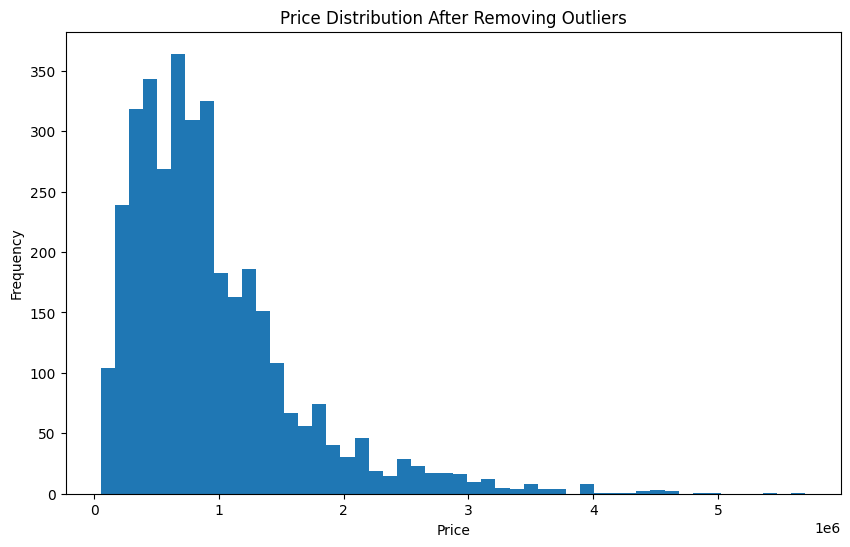

In [93]:
# First, let's check how many rows we have before removing outliers
print(f"Original dataframe size: {len(df_clean)}")

# Calculate IQR for each municipality and identify outliers
outliers_mask = pd.Series(False, index=df_clean.index)

# Only process municipalities with enough data points
min_properties = 5  # Minimum number of properties needed to calculate reliable statistics
municipality_counts = df_clean['municipality'].value_counts()
valid_municipalities = municipality_counts[municipality_counts >= min_properties].index

for municipality in valid_municipalities:
    # Get prices for this municipality
    municipality_prices = df_clean[df_clean['municipality'] == municipality]['price']
    
    # Calculate Q1, Q3 and IQR
    Q1 = municipality_prices.quantile(0.25)
    Q3 = municipality_prices.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for outliers (typically 1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers for this municipality
    municipality_outliers = df_clean[
        (df_clean['municipality'] == municipality) & 
        ((df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound))
    ].index
    
    # Add to our overall outliers mask
    outliers_mask.loc[municipality_outliers] = True
    
    # Print some stats
    outlier_count = len(municipality_outliers)
    if outlier_count > 0:
        print(f"Municipality: {municipality}, Outliers: {outlier_count}, " 
              f"Price range: {lower_bound:.2f} - {upper_bound:.2f}")

# For municipalities with too few properties, we can use global statistics
small_municipalities = df_clean['municipality'].isin(
    municipality_counts[municipality_counts < min_properties].index
)

if small_municipalities.sum() > 0:
    # Calculate global IQR
    all_prices = df_clean['price']
    global_Q1 = all_prices.quantile(0.25)
    global_Q3 = all_prices.quantile(0.75)
    global_IQR = global_Q3 - global_Q1
    
    global_lower = global_Q1 - 1.5 * global_IQR
    global_upper = global_Q3 + 1.5 * global_IQR
    
    # Identify outliers in small municipalities
    small_muni_outliers = df_clean[
        small_municipalities & 
        ((df_clean['price'] < global_lower) | (df_clean['price'] > global_upper))
    ].index
    
    # Add to our overall outliers mask
    outliers_mask.loc[small_muni_outliers] = True
    
    print(f"\nSmall municipalities (< {min_properties} properties): "
          f"Outliers: {len(small_muni_outliers)}, "
          f"Global price range: {global_lower:.2f} - {global_upper:.2f}")

# Remove the outliers
df_clean_no_outliers = df_clean[~outliers_mask].copy()

# Print summary
total_outliers = outliers_mask.sum()
print(f"\nTotal outliers removed: {total_outliers} ({total_outliers/len(df_clean)*100:.2f}%)")
print(f"Dataframe size after removing outliers: {len(df_clean_no_outliers)}")

# Replace the original dataframe with the cleaned one
df_clean = df_clean_no_outliers

# Show the price distribution after removing outliers
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df_clean['price'], bins=50)
plt.title('Price Distribution After Removing Outliers')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [94]:
# Box plot 
def boxplot(df_func,col):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df_func[col])
    plt.title(col+' Box Plot')
    plt.xlabel('Number of '+col)
    plt.show()

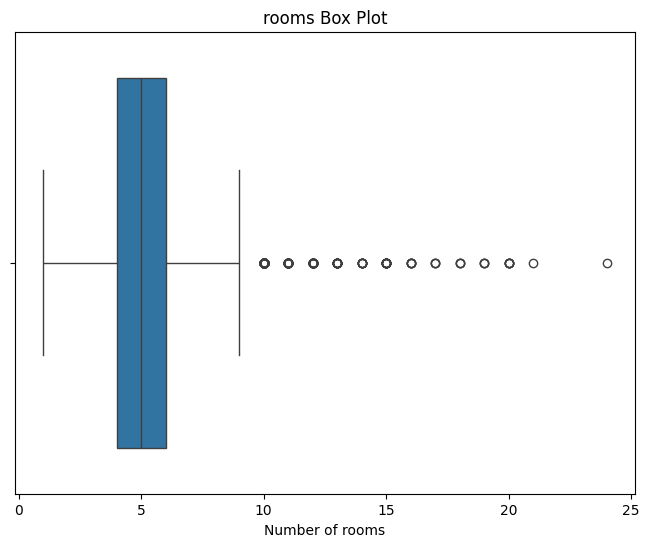

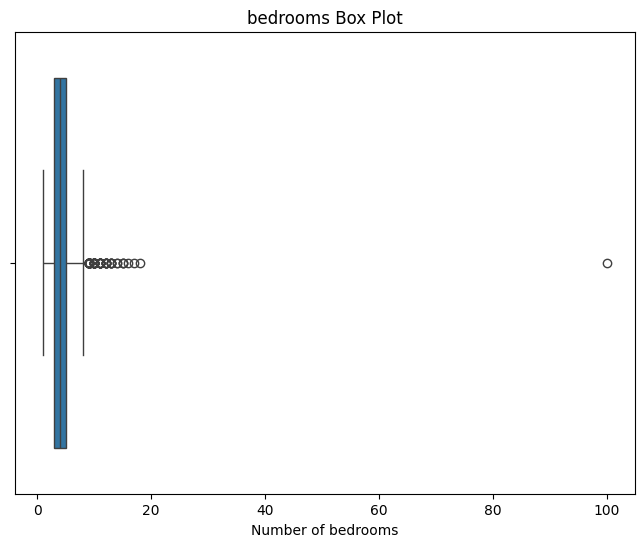

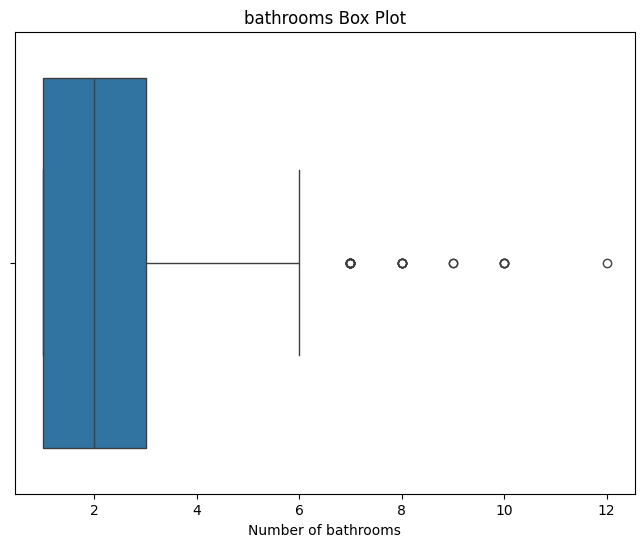

In [95]:
boxplot(df_clean,'rooms') 
boxplot(df_clean,'bedrooms')
boxplot(df_clean,'bathrooms')

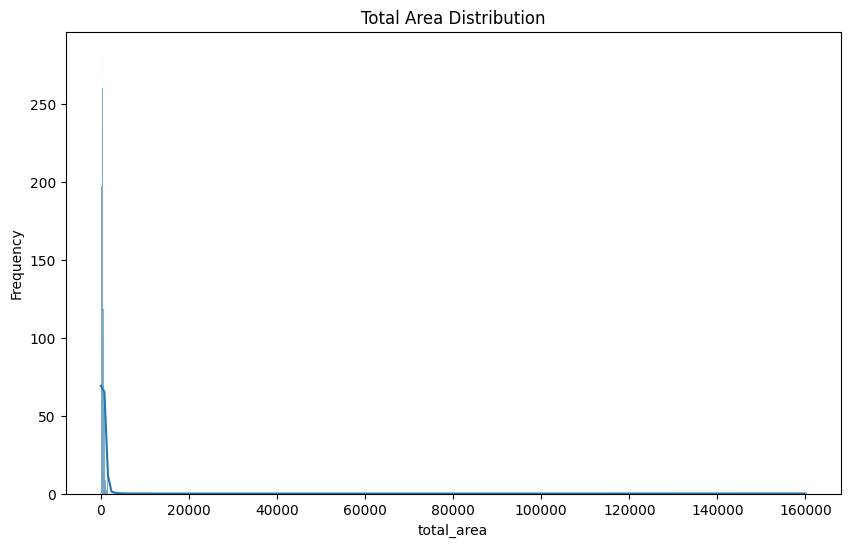

In [96]:

plot_distribution(df_clean['total_area'],'Total Area Distribution','total_area')


In [97]:

print(df_clean.shape)
# Method 1: IQR (Interquartile Range) method
def remove_outliers_iqr(df, column, k=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Try the IQR method
for col in ["total_area"]:
    df_clean = remove_outliers_iqr(df_clean, col)
    print(f"After IQR outlier removal on {col}: {df_clean.shape}")



(3580, 18)
After IQR outlier removal on total_area: (3343, 18)


In [98]:
def remove_outliers_zscore(df, column, threshold=3):
    # Calculate the Z-score for each data point
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    # Filter out the outliers
    return df[np.abs(z_scores) < threshold]

In [99]:

print(df_clean.shape)
for col in ['bedrooms','rooms','bathrooms']:
    df_clean=remove_outliers_zscore(df_clean,col)
    print(df_clean.shape)


(3343, 18)
(3325, 18)
(3281, 18)
(3263, 18)


## 2-Feature engineering and selection

(640, 18)


<Axes: xlabel='latitude', ylabel='longitude'>

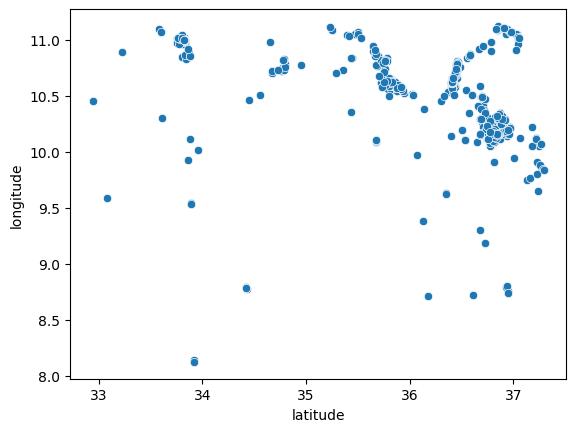

In [100]:
# Drop duplicate rows based on latitude and longitude
data_geo = df_clean.drop_duplicates(subset=['latitude', 'longitude'])
# Reset index to ensure no duplicate labels
data_geo.reset_index(drop=True, inplace=True)
print(data_geo.shape)
# Plot the scatterplot
sns.scatterplot(x='latitude', y='longitude', data=data_geo)

In [101]:
# Round latitude and longitude to 4 decimal places
df_clean['latitude'] = df_clean['latitude'].round(4)
df_clean['longitude'] = df_clean['longitude'].round(4)
# Check the rounded values
print(df_clean[['latitude', 'longitude']].head())

   latitude  longitude
0   36.8764    10.3253
2   36.3884    10.5515
4   36.4011    10.6146
5   36.4011    10.6146
7   36.8355    10.2242


In [102]:
df_clean.groupby('municipality')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
municipality,,,,,,,,
Ajim (Djerba),157.0,5.566743e+05,2.103178e+05,220000.00,394740.000,502300.00,689800.00,1148560.00
Akouda,38.0,1.031832e+06,1.081165e+06,60000.00,499480.345,680000.00,1165160.18,4889950.78
Ariana,169.0,1.017979e+06,5.050648e+05,135000.00,600000.000,980000.00,1300000.00,2300000.00
Aïn Draham,2.0,1.225000e+05,3.889087e+04,95000.00,108750.000,122500.00,136250.00,150000.00
Bembla-Mnara,2.0,2.190000e+05,6.929646e+04,170000.00,194500.000,219000.00,243500.00,268000.00
...,...,...,...,...,...,...,...,...
Téboulba,5.0,3.207321e+05,1.667640e+05,170000.00,200000.000,260000.00,400000.00,573660.36
Zaghouan,4.0,5.600000e+05,2.887906e+05,300000.00,367500.000,495000.00,687500.00,950000.00
Zaouiet Sousse,1.0,1.978145e+05,NaN,197814.50,197814.500,197814.50,197814.50,197814.50


In [103]:
# Calculate average price per municipality
municipality_avg_price = df_clean.groupby('municipality')['price'].mean().reset_index()
municipality_avg_price.columns = ['municipality', 'municipality_avg_price']
# Calculate average price per governorate
governorate_avg_price = df_clean.groupby('governorate')['price'].mean().reset_index()
governorate_avg_price.columns = ['governorate', 'governorate_avg_price']
df_clean = pd.merge(df_clean, municipality_avg_price, on='municipality', how='left')
df_clean = pd.merge(df_clean, governorate_avg_price, on='governorate', how='left')
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,bedrooms,garage,garden,pool,municipality,governorate,municipality_avg_price,governorate_avg_price
0,856000.0,Gammarth à La Marsa,405.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,36.8764,10.3253,4.0,0.0,0.0,0.0,La Marsa,Tunis,1.576904e+06,1.447628e+06
1,892000.0,Hammamet Sud à Hammamet,485.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,36.3884,10.5515,4.0,1.0,1.0,1.0,Hammamet,Nabeul,8.106595e+05,7.862180e+05
2,1250000.0,Hammamet Nord à Hammamet,370.0,5.0,3.0,1.0,0.0,1.0,1.0,0.0,36.4011,10.6146,4.0,1.0,1.0,1.0,Hammamet,Nabeul,8.106595e+05,7.862180e+05
3,1150000.0,Hammamet Sud à Hammamet,550.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,36.4011,10.6146,4.0,1.0,1.0,1.0,Hammamet,Nabeul,8.106595e+05,7.862180e+05
4,2200000.0,Les Berges Du Lac 1 à La Marsa,438.0,8.0,4.0,1.0,0.0,1.0,1.0,1.0,36.8355,10.2242,6.0,1.0,1.0,1.0,La Marsa,Tunis,1.576904e+06,1.447628e+06


In [104]:
def generate_quality(col):
    # Create municipality quality feature based on average prices
    # Group by municipality and calculate statistics
    stats = df_clean.groupby(col).agg({
        'price': ['mean', 'median', 'count']
    }).reset_index()

    # Flatten the multi-index columns
    stats.columns = [col, 'avg_price', 'median_price', 'property_count']

    # Separate reliable and unreliable
    min_samples = 3  # Minimum number of properties to consider reliable
    reliable = stats[stats['property_count'] >= min_samples]
    unreliable = stats[stats['property_count'] < min_samples]

    # Create quality tiers for reliable 
    if len(reliable) > 0:
        # Calculate price thresholds from reliable data
        low_threshold = reliable['avg_price'].quantile(0.33)
        high_threshold = reliable['avg_price'].quantile(0.67)
        
        # Create quality tiers using calculated thresholds
        reliable['price_tier'] = pd.cut(
            reliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['low_income_area', 'middle_income_area', 'high_income_area']
        )
        reliable['confidence'] = 'high'
    if len(unreliable) > 0:
        # Apply the same thresholds to unreliable municipalities
        unreliable['price_tier'] = pd.cut(
            unreliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['low_income_area', 'middle_income_area', 'high_income_area']
        )
        unreliable['confidence'] = 'low'
        
    # Combine all municipalities
    all_municipalities = pd.concat([reliable, unreliable]) 
    # Create mapping dictionaries
    quality_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['price_tier']
    ))
        
    confidence_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['confidence']
    ))
    return quality_map,confidence_map


In [105]:
# Apply the mappings to create new features
municipality_quality_map_mun,municipality_confidence_map_mun=generate_quality('municipality')
df_clean['municipality_quality'] = df_clean['municipality'].map(municipality_quality_map_mun)
df_clean['municipality_quality_confidence'] = df_clean['municipality'].map(municipality_confidence_map_mun)

municipality_quality_map_gov,municipality_confidence_map_gov=generate_quality('governorate')
df_clean['governorate_quality'] = df_clean['governorate'].map(municipality_quality_map_gov)
df_clean['governorate_quality_confidence'] = df_clean['governorate'].map(municipality_confidence_map_gov)


df_clean.head()

C:\Users\MSI\AppData\Local\Temp\ipykernel_15968\4020268722.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['price_tier'] = pd.cut(
C:\Users\MSI\AppData\Local\Temp\ipykernel_15968\4020268722.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['confidence'] = 'high'
C:\Users\MSI\AppData\Local\Temp\ipykernel_15968\4020268722.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,...,garden,pool,municipality,governorate,municipality_avg_price,governorate_avg_price,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,856000.0,Gammarth à La Marsa,405.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,La Marsa,Tunis,1.576904e+06,1.447628e+06,high_income_area,high,high_income_area,high
1,892000.0,Hammamet Sud à Hammamet,485.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,Hammamet,Nabeul,8.106595e+05,7.862180e+05,high_income_area,high,middle_income_area,high
2,1250000.0,Hammamet Nord à Hammamet,370.0,5.0,3.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,Hammamet,Nabeul,8.106595e+05,7.862180e+05,high_income_area,high,middle_income_area,high
3,1150000.0,Hammamet Sud à Hammamet,550.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,Hammamet,Nabeul,8.106595e+05,7.862180e+05,high_income_area,high,middle_income_area,high
4,2200000.0,Les Berges Du Lac 1 à La Marsa,438.0,8.0,4.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,La Marsa,Tunis,1.576904e+06,1.447628e+06,high_income_area,high,high_income_area,high


In [106]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            3263 non-null   float64
 1   address                          3263 non-null   object 
 2   total_area                       3263 non-null   float64
 3   rooms                            3263 non-null   float64
 4   bathrooms                        3263 non-null   float64
 5   terrace                          3263 non-null   float64
 6   furnished                        3263 non-null   float64
 7   air_conditioning                 3263 non-null   float64
 8   heating                          3263 non-null   float64
 9   security                         3263 non-null   float64
 10  latitude                         3263 non-null   float64
 11  longitude                        3263 non-null   float64
 12  bedrooms            

### Encoding

In [107]:
df_clean.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool', 'municipality',
       'governorate', 'municipality_avg_price', 'governorate_avg_price',
       'municipality_quality', 'municipality_quality_confidence',
       'governorate_quality', 'governorate_quality_confidence'],
      dtype='object')

In [108]:
# Using pandas get_dummies for categorical variables
import pandas as pd

# List of categorical columns to convert
categorical_columns = [  'municipality_quality', 'municipality_quality_confidence',
       'governorate_quality', 'governorate_quality_confidence']

# Filter to only include columns that exist in the dataframe
categorical_columns = [col for col in categorical_columns if col in df_clean.columns]

if categorical_columns:
    # Create dummy variables and drop original columns
    df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=False)
else:
    print("No categorical columns found in the dataframe")

In [109]:
df_clean=df_clean.drop(columns=['municipality','governorate','address'],axis=1)

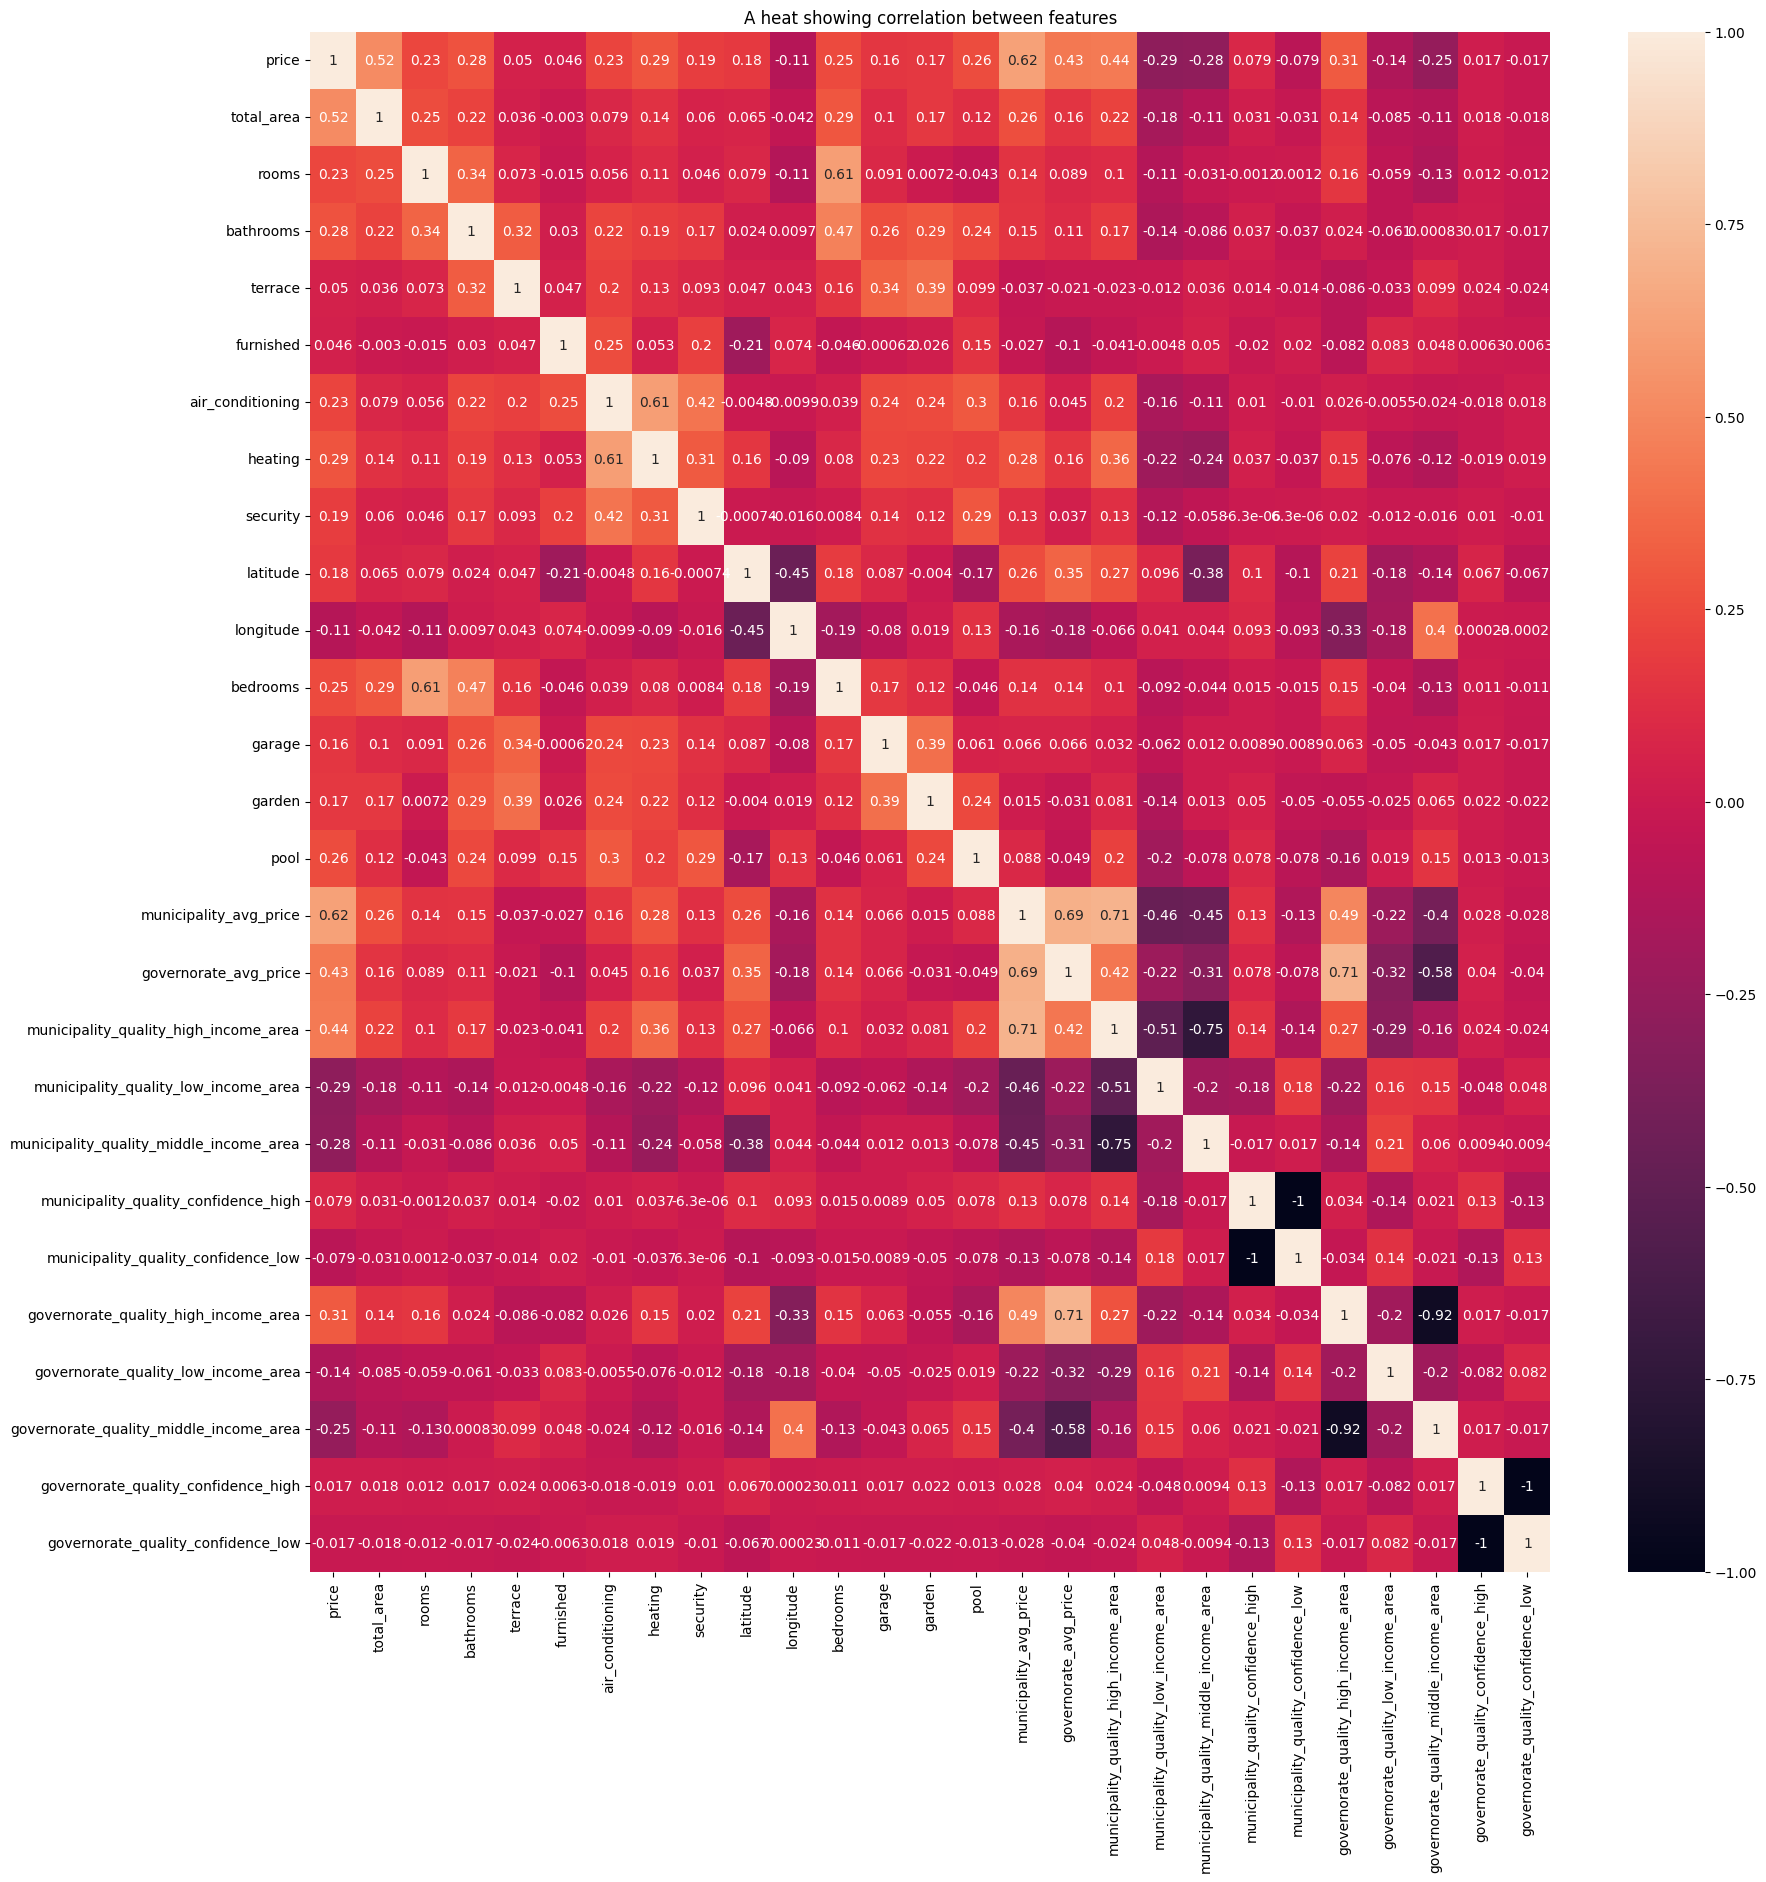

In [110]:
plt.figure(figsize=(20, 20))
sns.heatmap(df_clean.corr(), annot=True)
plt.title("A heat showing correlation between features")
plt.show()


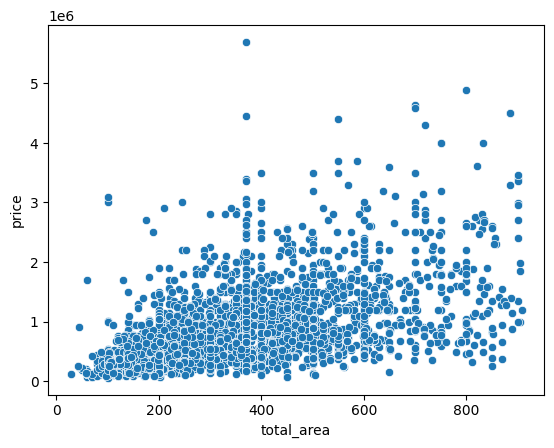

In [111]:
sns.scatterplot(x='total_area',y='price',data=df_clean)
plt.show()

In [112]:
#df_clean.to_csv('generate_from.csv',index=False)

In [ ]:
df_clean=pd.read_csv('synthatic_data_maison_acheter.csv')
df_clean=df_clean.dropna()

## Modeling

In [115]:
df_clean.columns

Index(['price', 'total_area', 'rooms', 'bathrooms', 'terrace', 'furnished',
       'air_conditioning', 'heating', 'security', 'latitude', 'longitude',
       'bedrooms', 'garage', 'garden', 'pool', 'municipality_avg_price',
       'governorate_avg_price', 'municipality_quality_high_income_area',
       'municipality_quality_low_income_area',
       'municipality_quality_middle_income_area',
       'municipality_quality_confidence_high',
       'municipality_quality_confidence_low',
       'governorate_quality_high_income_area',
       'governorate_quality_low_income_area',
       'governorate_quality_middle_income_area',
       'governorate_quality_confidence_high',
       'governorate_quality_confidence_low'],
      dtype='object')

In [121]:
X=df_clean.drop(columns=['price','governorate_quality_confidence_low','governorate_quality_middle_income_area',
                    'municipality_quality_confidence_low','municipality_quality_middle_income_area','security'],axis=1)
y=df_clean['price']
print(X.shape)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

(13047, 21)


In [123]:
# Define MAPE and MdAPE functions
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def median_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [ ]:
# Define the function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name=None):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    # Calculate MAPE and MdAPE
    train_mape = mean_absolute_percentage_error(y_train, train_pred)
    test_mape = mean_absolute_percentage_error(y_test, test_pred)
    train_mdape = median_absolute_percentage_error(y_train, train_pred)
    test_mdape = median_absolute_percentage_error(y_test, test_pred)
    
    name = model_name if model_name else model.__class__.__name__
    print(f"\nModel: {name}")
    print(f"Training R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"Training MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"Training RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
    print(f"Training MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%")
    print(f"Training MdAPE: {train_mdape:.2f}%, Test MdAPE: {test_mdape:.2f}%")
    print(f"R² Difference (Overfitting): {train_r2 - test_r2:.4f}")

In [147]:
from sklearn.model_selection import cross_val_score
def cross_val_evaluate(model):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-validation R² scores: {cv_scores}")
    print(f"Mean CV R² score: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV R² scores: {np.std(cv_scores):.4f}")

    # Get feature importances
    feature_importances = model.feature_importances_
    features = X_train.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()  # Display the most important feature at the top
    plt.tight_layout()
    plt.show()

#### Linear Regression

In [144]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
# Add StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test,"Linear Regression")



Model: Linear Regression
Training R²: 0.5635, Test R²: 0.5680
Training MAE: 261874.11, Test MAE: 264888.96
Training RMSE: 373946.57, Test RMSE: 375331.06
Training MAPE: 51.38%, Test MAPE: 53.60%
Training MdAPE: 29.59%, Test MdAPE: 30.33%
R² Difference (Overfitting): -0.0044


### Random forest

In [ ]:
# Hyperparameter tuning for Random Forest with focus on reducing overfitting
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
# Define the parameter distribution with more regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Include more restrictive depths
    'min_samples_split': [5, 10, 15, 20, 25],  # Increase minimum samples for splits
    'min_samples_leaf': [2, 4, 6, 8, 10],      # Increase minimum samples for leaves
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap': [True],
    'oob_score': [True],
    'max_samples': [0.7, 0.8, 0.9, None]  # Add subsampling to reduce overfitting
}
# Create a base Random Forest model
rf = RandomForestRegressor(random_state=42)
# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)
# Fit RandomizedSearchCV
print("Starting hyperparameter search...")
rf_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {rf_random.best_params_}")
print(f"Best cross-validation MSE: {-rf_random.best_score_:.2f}")

# Create a model with the best parameters
best_rf = RandomForestRegressor(**rf_random.best_params_, random_state=42)
evaluate_model(best_rf, X_train, X_test, y_train, y_test,"Random forest")

cross_val_evaluate(best_rf)


Starting hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'oob_score': True, 'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_samples': 0.7, 'max_features': 0.5, 'max_depth': 15, 'bootstrap': True}
Best cross-validation MSE: 116921108117.53

Model: Random forest
Training R²: 0.7387, Test R²: 0.6475
Training MAE: 195170.13, Test MAE: 232719.52
Training RMSE: 289306.66, Test RMSE: 339014.62
Training MAPE: 35.24%, Test MAPE: 43.90%
Training MdAPE: 21.24%, Test MdAPE: 25.24%
R² Difference (Overfitting): 0.0912


### GradientBoostingRegressor

Starting hyperparameter search for Gradient Boosting...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'subsample': 1.0, 'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 4, 'learning_rate': 0.05, 'alpha': 0.5}
Best cross-validation MSE: 112725898599.93

Model: Gradient boost regressor
Training R²: 0.7218, Test R²: 0.6562
Training MAE: 206518.68, Test MAE: 230087.63
Training RMSE: 298543.42, Test RMSE: 334830.56
Training MAPE: 37.29%, Test MAPE: 42.82%
Training MdAPE: 23.27%, Test MdAPE: 25.49%
R² Difference (Overfitting): 0.0656

Cross-validation R² scores: [0.66753392 0.6522153  0.64825798 0.63949503 0.6394526 ]
Mean CV R² score: 0.6494
Standard deviation of CV R² scores: 0.0103


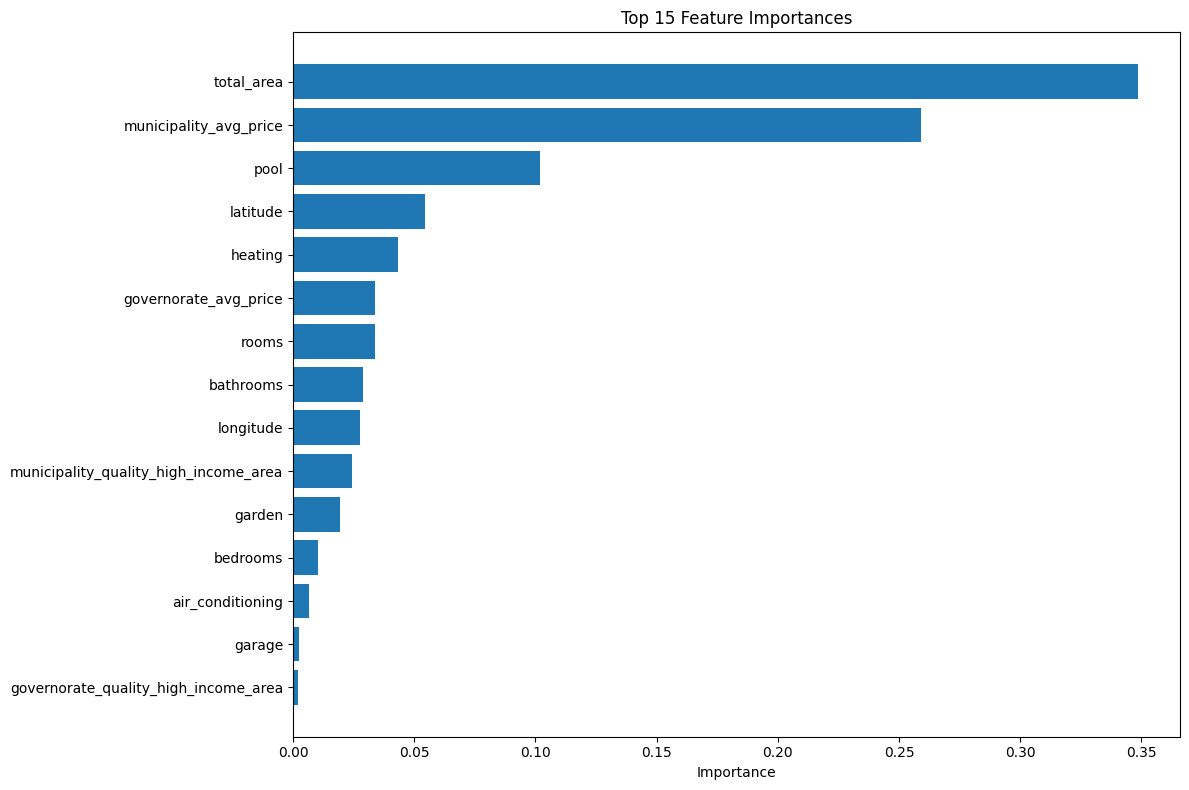

In [ ]:
# Hyperparameter tuning for Gradient Boosting with focus on reducing overfitting
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Define the parameter distribution with regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 5, 6, 8],  # GBM typically uses shallower trees than RF
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # Similar to max_samples in RF
    'alpha': [0.1, 0.5, 0.9]  # Alpha for quantile loss (controls robustness)
}

# Create a base Gradient Boosting model
sgb = GradientBoostingRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
sgb_random = RandomizedSearchCV(
    estimator=sgb,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search for Gradient Boosting...")
sgb_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {sgb_random.best_params_}")
print(f"Best cross-validation MSE: {-sgb_random.best_score_:.2f}")
# Create a model with the best parameters
best_sgb = GradientBoostingRegressor(**sgb_random.best_params_, random_state=42)
evaluate_model(best_sgb, X_train, X_test, y_train, y_test,"Gradient boost regressor")
cross_val_evaluate(best_sgb)

### Ensemble 

In [151]:
# ... existing code ...
from sklearn.ensemble import VotingRegressor, StackingRegressor
# Define the best Lasso model

# Simple averaging ensemble (VotingRegressor) with Lasso added
voting_ensemble = VotingRegressor(
    estimators=[
        ('rf', best_rf),
        ('sgb', best_sgb),
    ],
    weights=[1, 1]  # Equal weights for all models
)

evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test,"Voting ensemble")


# Advanced stacking ensemble with a meta-learner and Lasso added
stacking_ensemble = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('sgb', best_sgb),
    ]
)
evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test,"Voting ensemble")


Model: Voting ensemble
Training R²: 0.7352, Test R²: 0.6570
Training MAE: 199036.65, Test MAE: 229749.70
Training RMSE: 291239.13, Test RMSE: 334406.35
Training MAPE: 35.87%, Test MAPE: 42.98%
Training MdAPE: 22.14%, Test MdAPE: 25.45%
R² Difference (Overfitting): 0.0782

Model: Voting ensemble
Training R²: 0.7352, Test R²: 0.6570
Training MAE: 199036.65, Test MAE: 229749.70
Training RMSE: 291239.13, Test RMSE: 334406.35
Training MAPE: 35.87%, Test MAPE: 42.98%
Training MdAPE: 22.14%, Test MdAPE: 25.45%
R² Difference (Overfitting): 0.0782


### Deep learning

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define neural network for regression
class RealEstateNN(nn.Module):
    def __init__(self, input_dim):
        super(RealEstateNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Train and evaluate the model
def train_and_evaluate_nn(X_train, y_train, X_test, y_test, epochs=300, batch_size=64):
    # Scale features
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Log transform the target for better training
    y_train_log = np.log1p(y_train)
    
    # Scale the log-transformed target
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train_log.values.reshape(-1, 1)).flatten()
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    y_train_tensor = torch.FloatTensor(y_train_scaled)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    
    # Create dataset and dataloader
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    input_dim = X_train.shape[1]
    model = RealEstateNN(input_dim)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            # Forward pass
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        scheduler.step(avg_loss)
        
        # Print progress
        if (epoch+1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    # Evaluation on original price scale
    model.eval()
    with torch.no_grad():
        # Get predictions
        y_pred_scaled = model(X_test_tensor).squeeze().numpy()
        
        # Convert back to log space
        y_pred_log = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        
        # Convert from log space to original price
        y_pred = np.expm1(y_pred_log)
        
        # Calculate metrics on original price scale
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        mdape = median_absolute_percentage_error(y_test, y_pred)

        print("\nNeural Network Performance (Original Price Scale):")
        print(f"MAE: {mae:.2f} TND")
        print(f"RMSE: {rmse:.2f} TND")
        print(f"R²: {r2:.4f}")
        print("mape:",mape)
        print("mdape",mdape)
    
    return model, y_pred

# Train and evaluate the model
model, predictions = train_and_evaluate_nn(X_train, y_train, X_test, y_test)